In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
import xgboost 

from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, 
)

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


In [2]:

df = pd.read_csv('Copia de data_merged.csv')



In [4]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

df_processed['duration_ms'] = df_processed['duration_ms']/60000

def categorize_popularity(popularity):
    if popularity == 0:
        return 0 #no popular
    elif popularity<=20:
        return 1 # baja
    elif popularity <=40:
        return 2 # media
    return 3 # alta

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['no popular','Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")




Variable multiclase 3 niveles (popularity_multiclass):
   0 (no popular): 39729 (23.1%)
   1 (Baja): 34033 (19.8%)
   2 (Media): 51035 (29.6%)
   3 (Alta): 47433 (27.5%)


<Axes: xlabel='popularity_multiclass'>

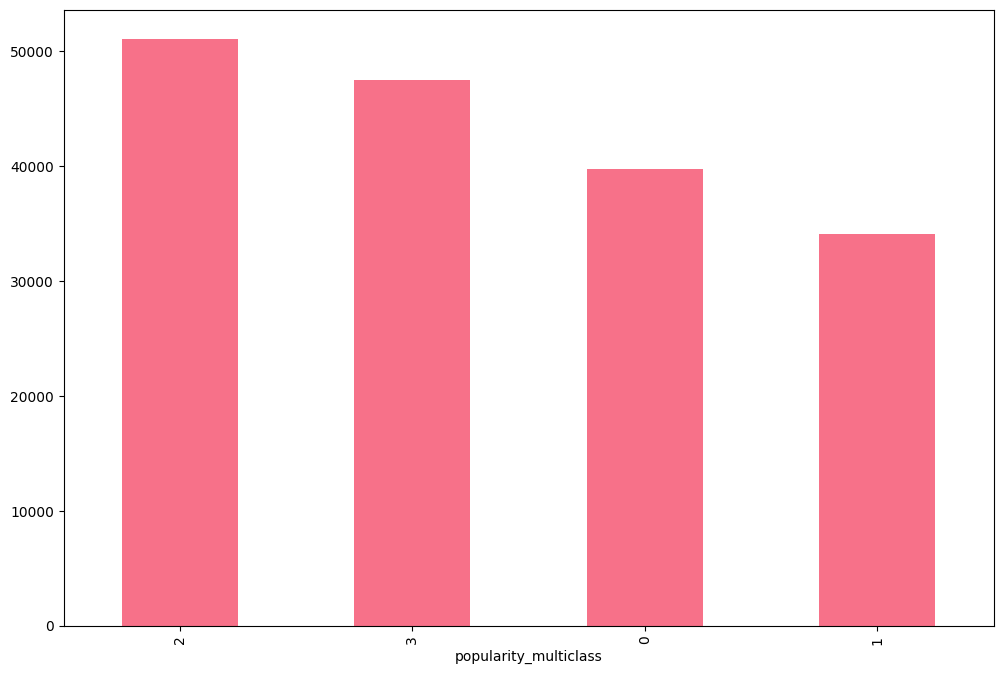

In [5]:
df_processed['popularity_multiclass'].value_counts().plot(kind='bar')

In [6]:


_X = df_processed.copy()

X = _X.drop(columns=['popularity','popularity_multiclass'])
y_multiclass_3 = df_processed['popularity_multiclass'] 



In [7]:
df_processed.groupby('popularity_multiclass')['popularity'].describe()

,count,mean,std,min,25%,50%,75%,max
popularity_multiclass,,,,,,,,
0,39729.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,34033.0,9.619575,6.125172,1.0,4.0,9.0,15.0,20.0
2,51035.0,30.747330,5.652618,21.0,26.0,31.0,36.0,40.0
3,47433.0,54.153163,9.966513,41.0,46.0,52.0,61.0,100.0


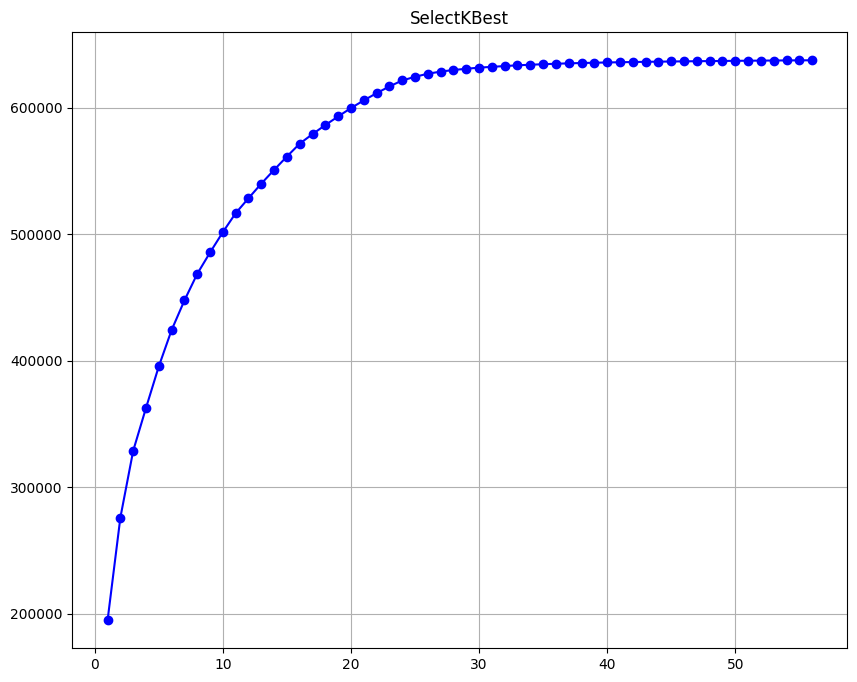

In [23]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif,k='all')
X_new = selector.fit_transform(X,y_multiclass_3)
total_score = selector.scores_
sorted_scoress = np.cumsum(sorted(total_score,reverse=True))
plt.figure(figsize=(10,8))
plt.grid(visible=True)
plt.plot(range(1,X.shape[1]+1),sorted_scoress,'bo-')
plt.title("SelectKBest")
plt.savefig("anova.png",dpi=421)


In [8]:
selector = SelectKBest(score_func=f_classif,k=6)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select


array(['popularity_ar', 'acousticness_yr', 'energy_yr',
       'instrumentalness_yr', 'tempo_yr', 'popularity_yr'], dtype=object)

In [9]:
_X=X[select]
y =y_multiclass_3

In [10]:
scaler1 = StandardScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)


In [11]:
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END estimator__max_depth=None, estimator__n_estimators=100; total time= 3.3min
[CV] END estimator__max_depth=None, estimator__n_estimators=100; total time= 3.3min
[CV] END estimator__max_depth=None, estimator__n_estimators=100; total time= 3.3min
[CV] END estimator__max_depth=None, estimator__n_estimators=100; total time= 3.3min
[CV] END estimator__max_depth=None, estimator__n_estimators=100; total time= 3.3min
[CV] END estimator__max_depth=None, estimator__n_estimators=300; total time=10.7min
[CV] END estimator__max_depth=None, estimator__n_estimators=300; total time=10.8min
[CV] END estimator__max_depth=None, estimator__n_estimators=300; total time=10.8min
[CV] END estimator__max_depth=10, estimator__n_estimators=100; total time= 2.9min
[CV] END estimator__max_depth=None, estimator__n_estimators=300; total time=11.2min
[CV] END estimator__max_depth=None, estimator__n_estimators=300; total time=11.3min
[CV] END estimator

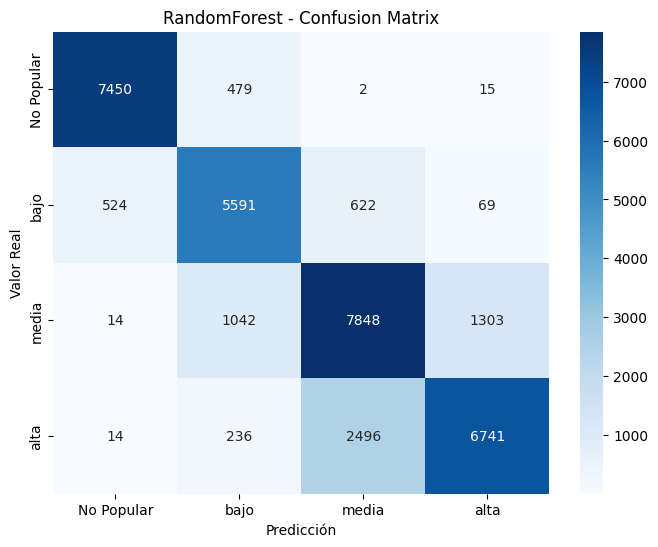

train

RandomForest
Best params: {'estimator__max_depth': 20, 'estimator__n_estimators': 100}
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     31783
           1       0.81      0.88      0.84     27227
           2       0.78      0.83      0.80     40828
           3       0.90      0.77      0.83     37946

    accuracy                           0.85    137784
   macro avg       0.86      0.86      0.86    137784
weighted avg       0.86      0.85      0.85    137784



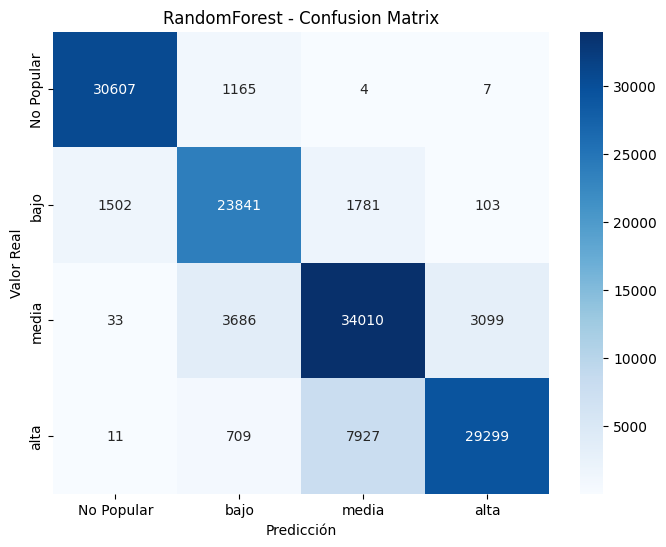

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ....estimator__max_depth=3, estimator__max_iter=100; total time=  17.7s
[CV] END ....estimator__max_depth=3, estimator__max_iter=100; total time=  17.7s
[CV] END ....estimator__max_depth=3, estimator__max_iter=100; total time=  17.8s
[CV] END ....estimator__max_depth=3, estimator__max_iter=100; total time=  17.7s
[CV] END ....estimator__max_depth=3, estimator__max_iter=100; total time=  17.7s
[CV] END ....estimator__max_depth=3, estimator__max_iter=200; total time=  32.7s
[CV] END ....estimator__max_depth=3, estimator__max_iter=200; total time=  32.7s
[CV] END ....estimator__max_depth=3, estimator__max_iter=200; total time=  33.0s
[CV] END ....estimator__max_depth=3, estimator__max_iter=200; total time=  32.8s
[CV] END ....estimator__max_depth=3, estimator__max_iter=200; total time=  32.9s
[CV] END ....estimator__max_depth=3, estimator__max_iter=300; total time=  45.1s
[CV] END ....estimator__max_depth=5, estimator__m

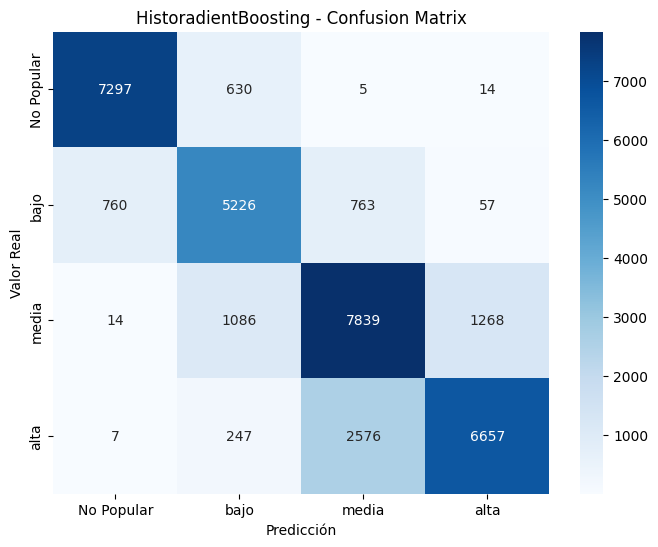

train

HistoradientBoosting
Best params: {'estimator__max_depth': 5, 'estimator__max_iter': 300}
              precision    recall  f1-score   support

           0       0.91      0.92      0.92     31783
           1       0.73      0.78      0.76     27227
           2       0.71      0.78      0.74     40828
           3       0.85      0.71      0.77     37946

    accuracy                           0.79    137784
   macro avg       0.80      0.80      0.80    137784
weighted avg       0.80      0.79      0.79    137784



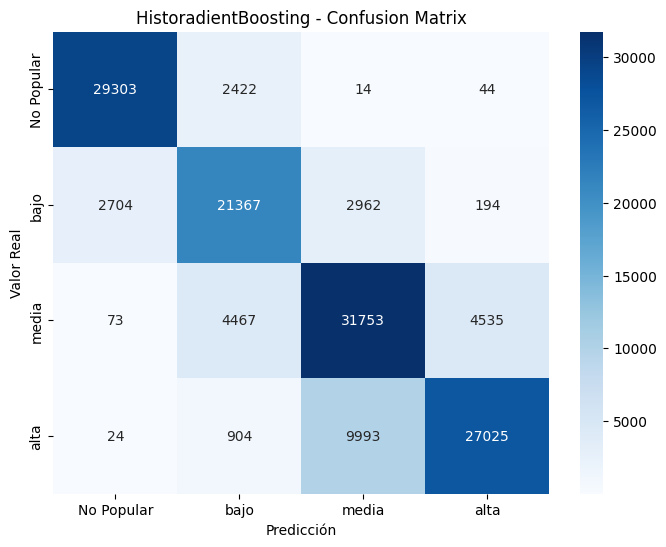

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END estimator__max_depth=3, estimator__n_estimators=100; total time=  33.2s
[CV] END estimator__max_depth=3, estimator__n_estimators=100; total time=  33.2s
[CV] END estimator__max_depth=3, estimator__n_estimators=100; total time=  33.3s
[CV] END estimator__max_depth=3, estimator__n_estimators=100; total time=  33.4s
[CV] END estimator__max_depth=3, estimator__n_estimators=100; total time=  33.4s
[CV] END estimator__max_depth=3, estimator__n_estimators=300; total time= 1.5min
[CV] END estimator__max_depth=3, estimator__n_estimators=300; total time= 1.5min
[CV] END estimator__max_depth=3, estimator__n_estimators=300; total time= 1.5min
[CV] END estimator__max_depth=3, estimator__n_estimators=300; total time= 1.5min
[CV] END estimator__max_depth=3, estimator__n_estimators=300; total time= 1.5min
[CV] END estimator__max_depth=10, estimator__n_estimators=100; total time=  43.8s
[CV] END estimator__max_depth=10, estimator__n_e

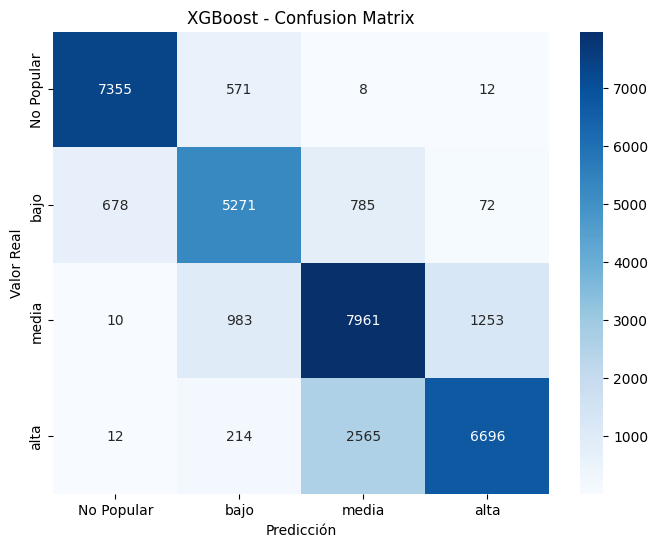

train

XGBoost
Best params: {'estimator__max_depth': 10, 'estimator__n_estimators': 100}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     31783
           1       0.78      0.81      0.79     27227
           2       0.73      0.81      0.77     40828
           3       0.87      0.73      0.79     37946

    accuracy                           0.82    137784
   macro avg       0.83      0.82      0.82    137784
weighted avg       0.82      0.82      0.82    137784



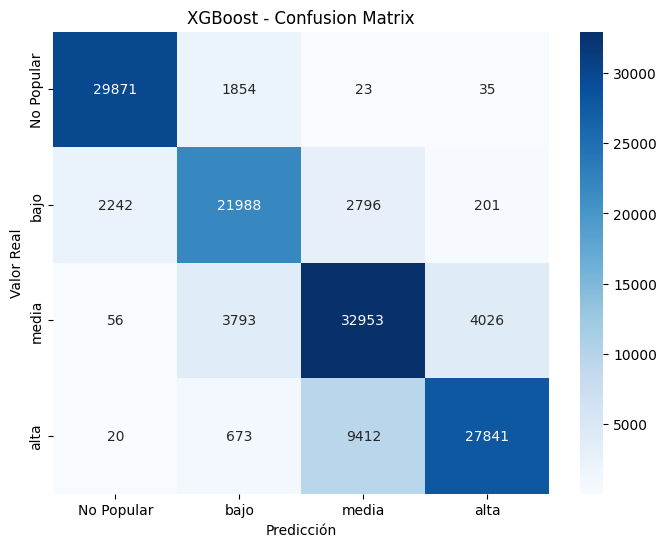

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END estimator__max_depth=None, estimator__n_estimators=100; total time= 3.5min
[CV] END estimator__max_depth=None, estimator__n_estimators=100; total time= 3.4min
[CV] END estimator__max_depth=None, estimator__n_estimators=100; total time= 3.4min
[CV] END estimator__max_depth=None, estimator__n_estimators=100; total time= 3.5min
[CV] END estimator__max_depth=None, estimator__n_estimators=100; total time= 3.5min
[CV] END estimator__max_depth=None, estimator__n_estimators=300; total time=10.5min
[CV] END estimator__max_depth=None, estimator__n_estimators=300; total time=10.5min
[CV] END estimator__max_depth=None, estimator__n_estimators=300; total time=10.5min
[CV] END estimator__max_depth=10, estimator__n_estimators=100; total time= 1.9min
[CV] END estimator__max_depth=None, estimator__n_estimators=300; total time= 9.9min
[CV] END estimator__max_depth=None, estimator__n_estimators=300; total time=10.0min
[CV] END estimator

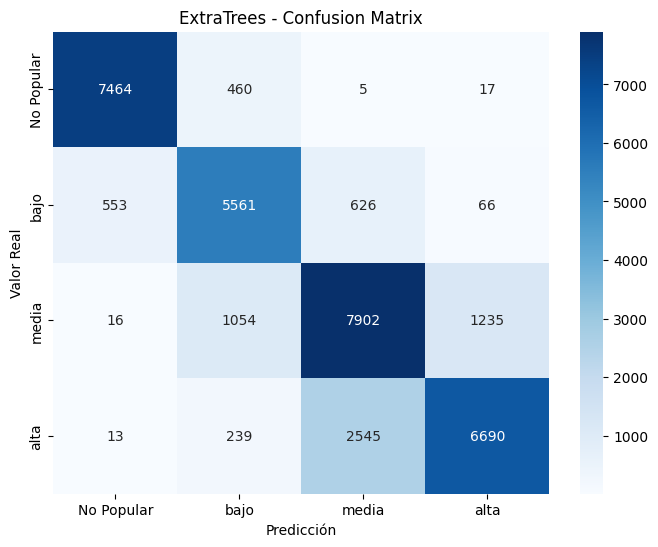

train

ExtraTrees
Best params: {'estimator__max_depth': 20, 'estimator__n_estimators': 500}
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     31783
           1       0.81      0.88      0.84     27227
           2       0.77      0.82      0.80     40828
           3       0.89      0.76      0.82     37946

    accuracy                           0.85    137784
   macro avg       0.86      0.86      0.85    137784
weighted avg       0.85      0.85      0.85    137784



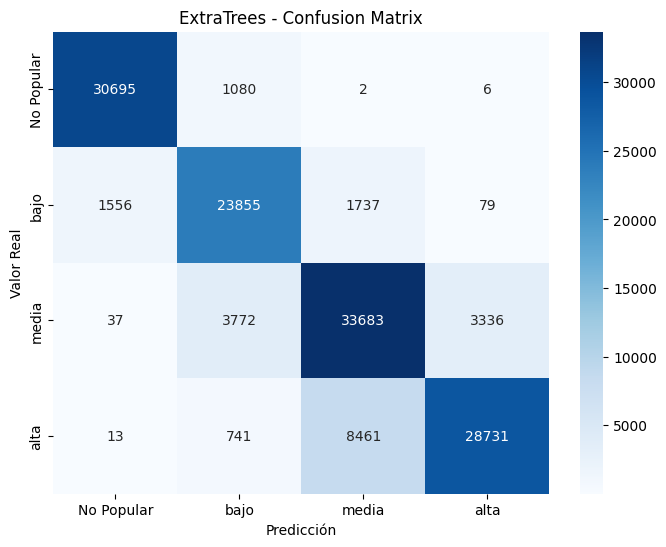

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END ............................estimator__max_depth=10; total time=   5.0s
[CV] END ............................estimator__max_depth=10; total time=   5.1s
[CV] END ............................estimator__max_depth=10; total time=   5.0s
[CV] END ..........................estimator__max_depth=None; total time=   6.3s
[CV] END ..........................estimator__max_depth=None; total time=   6.2s
[CV] END ..........................estimator__max_depth=None; total time=   6.4s
[CV] END ..........................estimator__max_depth=None; total time=   6.5s
[CV] END ..........................estimator__max_depth=None; total time=   6.5s
[CV] END ............................estimator__max_depth=10; total time=   4.6s
[CV] END ............................estimator__max_depth=10; total time=   4.8s
[CV] END ............................estimator__max_depth=20; total time=   5.7s
[CV] END ............................estimator__m

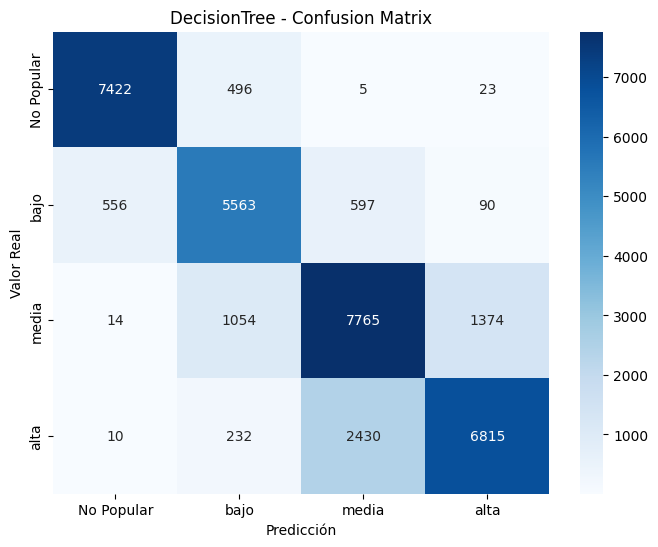

train

DecisionTree
Best params: {'estimator__max_depth': 20}
              precision    recall  f1-score   support

           0       0.95      0.96      0.95     31783
           1       0.80      0.88      0.84     27227
           2       0.78      0.82      0.80     40828
           3       0.89      0.77      0.83     37946

    accuracy                           0.85    137784
   macro avg       0.86      0.86      0.86    137784
weighted avg       0.85      0.85      0.85    137784



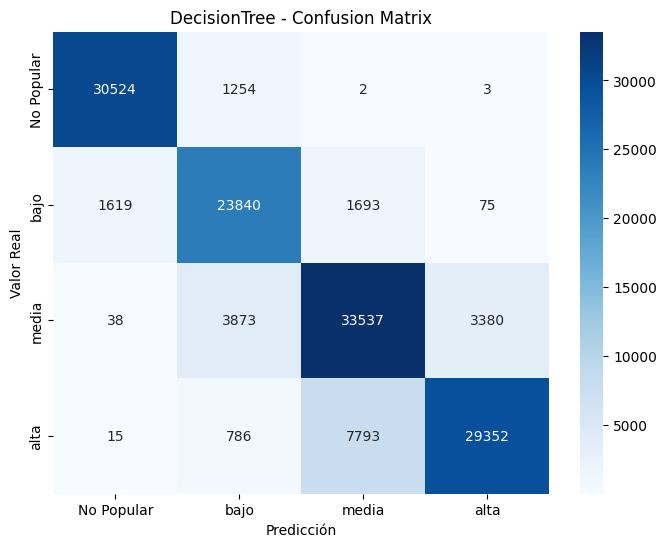

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ........estimator__C=0.001, estimator__max_iter=100; total time=   1.6s
[CV] END ........estimator__C=0.001, estimator__max_iter=100; total time=   1.7s
[CV] END ........estimator__C=0.001, estimator__max_iter=100; total time=   1.7s
[CV] END ........estimator__C=0.001, estimator__max_iter=100; total time=   1.7s
[CV] END ........estimator__C=0.001, estimator__max_iter=100; total time=   1.7s
[CV] END ........estimator__C=0.001, estimator__max_iter=200; total time=   1.7s
[CV] END ........estimator__C=0.001, estimator__max_iter=200; total time=   1.7s
[CV] END ........estimator__C=0.001, estimator__max_iter=200; total time=   1.7s
[CV] END ........estimator__C=0.001, estimator__max_iter=200; total time=   1.8s
[CV] END ........estimator__C=0.001, estimator__max_iter=200; total time=   1.9s
[CV] END ........estimator__C=0.001, estimator__max_iter=500; total time=   1.9s
[CV] END ........estimator__C=0.001, estimator__m

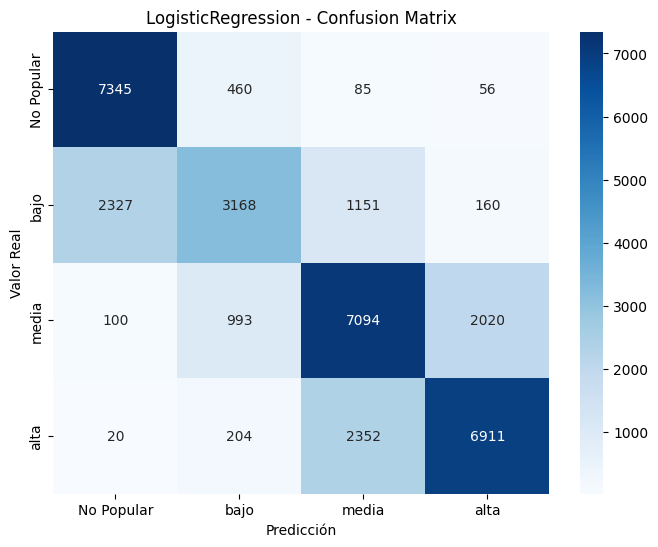

train

LogisticRegression
Best params: {'estimator__C': 0.001, 'estimator__max_iter': 100}
              precision    recall  f1-score   support

           0       0.76      0.92      0.83     31783
           1       0.66      0.48      0.56     27227
           2       0.67      0.70      0.68     40828
           3       0.76      0.73      0.75     37946

    accuracy                           0.72    137784
   macro avg       0.71      0.71      0.70    137784
weighted avg       0.71      0.72      0.71    137784



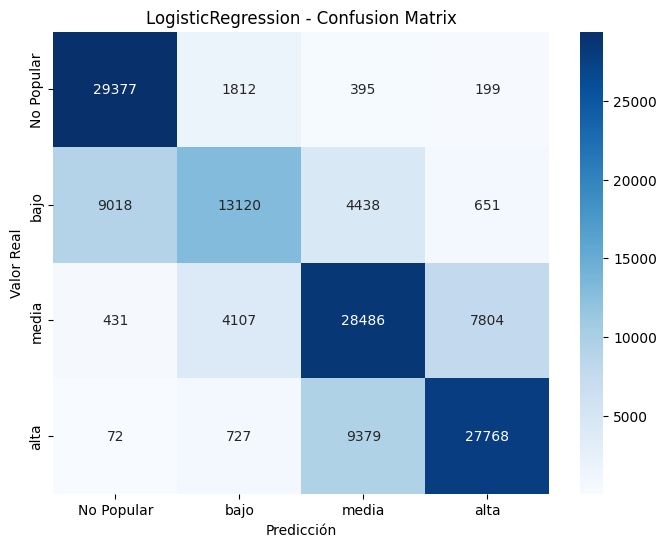

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END estimator__algorithm=ball_tree, estimator__n_neighbors=3, estimator__p=1; total time=  58.4s
[CV] END estimator__algorithm=ball_tree, estimator__n_neighbors=3, estimator__p=1; total time=  58.7s
[CV] END estimator__algorithm=ball_tree, estimator__n_neighbors=3, estimator__p=1; total time=  59.7s
[CV] END estimator__algorithm=ball_tree, estimator__n_neighbors=3, estimator__p=1; total time= 1.0min
[CV] END estimator__algorithm=ball_tree, estimator__n_neighbors=3, estimator__p=1; total time= 1.0min
[CV] END estimator__algorithm=ball_tree, estimator__n_neighbors=3, estimator__p=2; total time= 1.1min
[CV] END estimator__algorithm=ball_tree, estimator__n_neighbors=3, estimator__p=2; total time= 1.1min
[CV] END estimator__algorithm=ball_tree, estimator__n_neighbors=3, estimator__p=2; total time= 1.1min
[CV] END estimator__algorithm=ball_tree, estimator__n_neighbors=4, estimator__p=1; total time=  58.4s
[CV] END estimator__

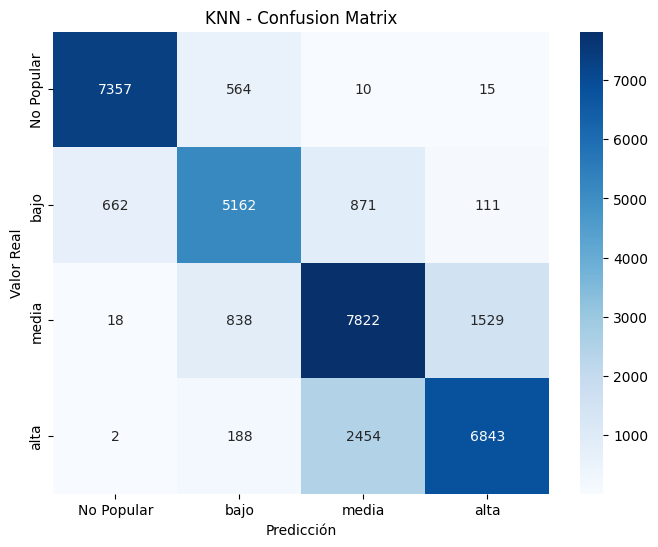

train

KNN
Best params: {'estimator__algorithm': 'auto', 'estimator__n_neighbors': 9, 'estimator__p': 2}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     31783
           1       0.79      0.79      0.79     27227
           2       0.74      0.81      0.77     40828
           3       0.85      0.75      0.80     37946

    accuracy                           0.82    137784
   macro avg       0.83      0.82      0.82    137784
weighted avg       0.82      0.82      0.82    137784



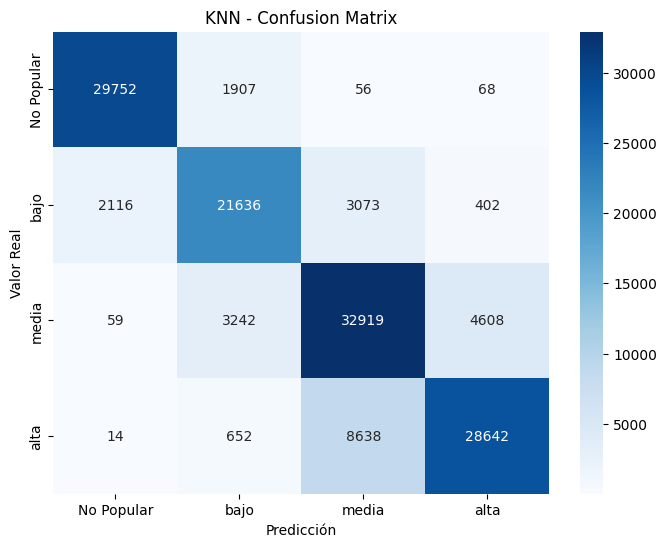

In [12]:
from sklearn.ensemble import ExtraTreesClassifier,HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
    'LogisticRegression':LogisticRegression(class_weight='balanced'),
    "KNN":KNeighborsClassifier()
}
param_grids = {
    'LogisticRegression':{
    'C':[0.001,0.1,10],
    'max_iter':[100,200,500],
    
    },
    'KNN':{
        'n_neighbors':[3,4,7,9],
        'algorithm':['ball_tree','auto','kd_tree','brute'],
        'p':[1,2]
    },
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],

    }
}
results = {}

for name, model in models.items():
    p=param_grids[name]
    new_p = {f"estimator__{x}":y for x,y in p.items()}
    grid = GridSearchCV(OneVsRestClassifier(model),new_p , cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    print("train")
    y_pred = best.predict(X_train_reduce)
    r = classification_report(y_train_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_train_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    results[name] = grid.best_params_